In [1]:
import pandas as pd

/tmp/ipykernel_49655/4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [52]:
pang_sizes = pd.read_csv('pangenome_sizes.tsv', sep = '\t')

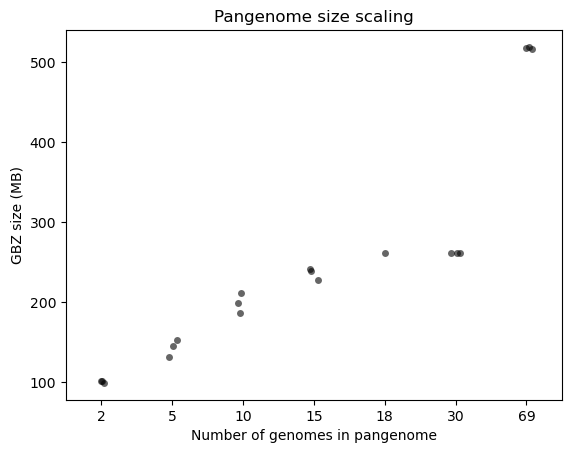

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
    "pangenome_sizes.tsv",
    sep="\t"
)

df["n_genomes"] = df["n_genomes"].replace("all", 69).astype(int)

sns.stripplot(
    data=df,
    x="n_genomes",
    y="gbz_size_mb",
    color="black",
    alpha=0.6
)

plt.xlabel("Number of genomes in pangenome")
plt.ylabel("GBZ size (MB)")
plt.title("Pangenome size scaling")
plt.savefig('pangenome_size.png')
plt.show()


In [55]:
import re
from pathlib import Path
import pandas as pd

In [2]:
BASE = Path.home() / "scratch/pang/pang_experiment/pangenomes"

def parse_vg_stats(stats_file):
    metrics = {}
    with open(stats_file) as f:
        for line in f:
            line = line.strip()

            if line.startswith("Total alignments:"):
                metrics["total_reads"] = int(line.split(":")[1])

            elif line.startswith("Total aligned:"):
                metrics["mapped_reads"] = int(line.split(":")[1])

            elif line.startswith("Total properly paired:"):
                metrics["properly_paired"] = int(line.split(":")[1])

            elif line.startswith("Mapping quality:"):
                m = re.search(r"mean ([\d\.]+), median (\d+)", line)
                if m:
                    metrics["mean_mapq"] = float(m.group(1))
                    metrics["median_mapq"] = int(m.group(2))

            elif line.startswith("Total time:"):
                # example: "Total time: 63599.7 seconds"
                metrics["mapping_time_sec"] = float(
                    line.replace("Total time:", "")
                        .replace("seconds", "")
                        .strip()
                )

            elif line.startswith("Speed:"):
                # example: "Speed: 1230.19 reads/second"
                metrics["reads_per_sec"] = float(
                    line.split()[1]
                )
            elif line.startswith("Total perfect:"):
                metrics["perfect_reads"] = int(line.split(":")[1])

            elif line.startswith("Total gapless"):
                metrics["gapless_reads"] = int(line.split(":")[1])


    return metrics



rows = []

for set_dir in BASE.glob("set_*_rep*"):
    set_name = set_dir.name              # set_10_rep2
    set_label = "_".join(set_name.split("_")[:2])  # set_10
    rep = set_name.split("_")[2]         # rep2

    # infer number of genomes
    n_lookup = {
        "set_02": 2,
        "set_05": 5,
        "set_10": 10,
        "set_15": 15,
        "set_18": 18,
        "set_30": 30,
        "set_all": 69
    }
    n_genomes = n_lookup.get(set_label)

    mapping_dir = set_dir / "mapping" / "seedmix"
    if not mapping_dir.exists():
        continue

    for sample_dir in mapping_dir.iterdir():
        if not sample_dir.is_dir():
            continue

        stats_file = sample_dir / f"{sample_dir.name}.stats.txt"
        if not stats_file.exists():
            continue

        stats = parse_vg_stats(stats_file)

        if "total_reads" not in stats:
            continue

        stats["pct_mapped"] = stats["mapped_reads"] / stats["total_reads"]
        stats["pct_perfect"] = stats["perfect_reads"] / stats["total_reads"]
        stats["pct_gapless"] = stats["gapless_reads"] / stats["total_reads"]
    

        rows.append({
            "set": set_label,
            "rep": rep,
            "sample": sample_dir.name,
            "n_genomes": n_genomes,
            **stats
        })


NameError: name 'Path' is not defined

In [57]:
df_map = pd.DataFrame(rows)
df_map.sort_values(["n_genomes", "rep", "sample"], inplace=True)
df_map.reset_index(drop=True, inplace=True)

In [58]:
df_map[df_map['sample'] == 'S1']

,set,rep,sample,n_genomes,total_reads,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,median_mapq,mapping_time_sec,reads_per_sec,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,66923781,35556040,62066852,67270378,45.3854,60,63599.7,1230.190,0.855368,0.454450,0.793291
8,set_02,rep2,S1,2,78239732,66903360,35162090,61934325,67253448,45.3895,60,64583.0,1211.460,0.855107,0.449415,0.791597
16,set_02,rep3,S1,2,78239732,66924581,35284486,62018143,67325952,45.7679,60,60924.8,1284.200,0.855378,0.450979,0.792668
24,set_05,rep1,S1,5,78239732,67576075,39728362,63953260,67730464,45.4519,60,73766.8,1060.640,0.863705,0.507777,0.817401
32,set_05,rep2,S1,5,78239732,67476568,39656554,63859635,67629620,45.6242,60,83034.5,942.256,0.862434,0.506860,0.816205
40,set_05,rep3,S1,5,78239732,67393420,39342461,63773772,67510078,45.9792,60,75967.8,1029.910,0.861371,0.502845,0.815107
48,set_10,rep1,S1,10,78239732,67963997,42461473,65151443,68086328,45.5644,60,92374.2,846.987,0.868663,0.542710,0.832716
56,set_10,rep2,S1,10,78239732,68206314,42722879,65378042,68247518,45.5174,60,129408.0,604.597,0.871761,0.546051,0.835612
64,set_10,rep3,S1,10,78239732,68162402,42745672,65327059,68271540,45.7500,60,104937.0,745.584,0.871199,0.546342,0.834960
72,set_15,rep1,S1,15,78239732,68649675,44333891,66207681,68687412,45.4276,60,111990.0,698.632,0.877427,0.566642,0.846216


In [59]:
df_map

,set,rep,sample,n_genomes,total_reads,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,median_mapq,mapping_time_sec,reads_per_sec,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,66923781,35556040,62066852,67270378,45.3854,60,63599.7,1230.190,0.855368,0.454450,0.793291
1,set_02,rep1,S2,2,50474180,43662311,23030370,40525283,43828552,45.0514,60,42436.4,1189.410,0.865043,0.456280,0.802891
2,set_02,rep1,S3,2,54308174,47391347,24989441,43893263,47670268,45.4686,60,44364.5,1224.140,0.872637,0.460141,0.808226
3,set_02,rep1,S4,2,58646998,49833789,26185683,46264439,49841474,44.6091,60,51376.7,1141.510,0.849724,0.446497,0.788863
4,set_02,rep1,S5,2,67755386,57913670,30386172,53670663,58134216,45.1005,60,57104.2,1186.520,0.854746,0.448469,0.792124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,set_all,rep1,S8,69,73950880,66865108,47049859,65458638,65723960,43.6843,60,384625.0,192.267,0.904183,0.636231,0.885164
136,set_all,rep2,S1,69,78239732,70775252,50254647,69296080,70328234,44.3385,60,356470.0,219.485,0.904595,0.642316,0.885689
137,set_all,rep2,S2,69,50474180,46184428,32508865,45227257,45752992,44.0185,60,237534.0,212.492,0.915011,0.644069,0.896047
138,set_all,rep2,S3,69,54308174,50140009,35414330,49076672,49910958,44.4698,60,254414.0,213.464,0.923250,0.652099,0.903670


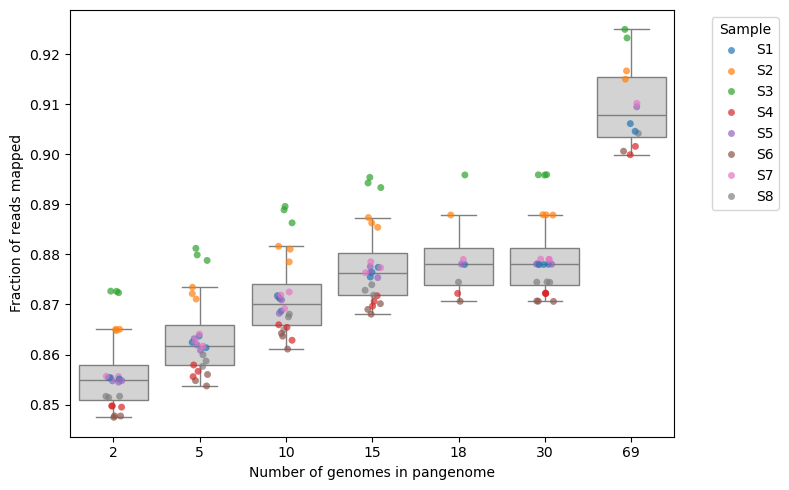

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Boxplot (no hue)
sns.boxplot(
    data=df_map,
    x="n_genomes",
    y="pct_mapped",
    color="lightgray",
    fliersize=0
)

# Stripplot with sample-based colors
sns.stripplot(
    data=df_map,
    x="n_genomes",
    y="pct_mapped",
    hue="sample",
    dodge=False,      # keep points centered per box
    alpha=0.7,
    size=5
)

plt.ylabel("Fraction of reads mapped")
plt.xlabel("Number of genomes in pangenome")

# Move legend outside (important, otherwise cluttered)
plt.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


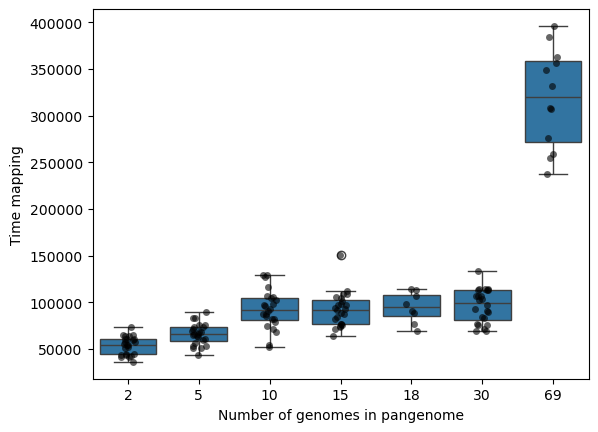

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_map,
    x="n_genomes",
    y="mapping_time_sec"
)

sns.stripplot(
    data=df_map,
    x="n_genomes",
    y="mapping_time_sec",
    color="black",
    alpha=0.6
)

plt.ylabel("Time mapping")
plt.xlabel("Number of genomes in pangenome")
plt.show()


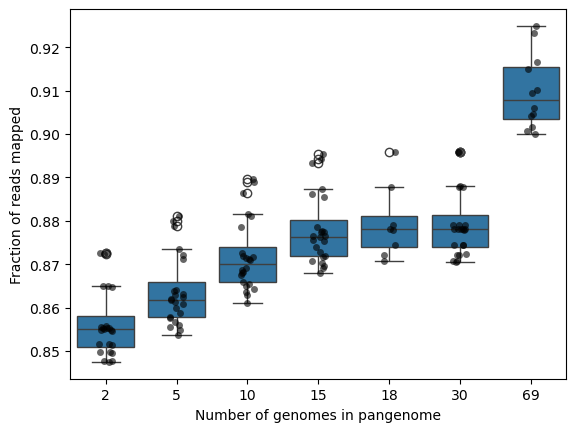

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_map,
    x="n_genomes",
    y="pct_mapped"
)

sns.stripplot(
    data=df_map,
    x="n_genomes",
    y="pct_mapped",
    color="black",
    alpha=0.6
)

plt.ylabel("Fraction of reads mapped")
plt.xlabel("Number of genomes in pangenome")
plt.show()


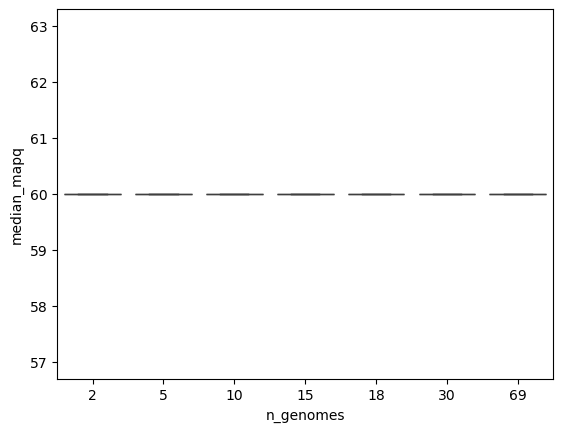

In [64]:
sns.boxplot(
    data=df_map,
    x="n_genomes",
    y="median_mapq"
)
plt.show()


In [3]:
def parse_flagstat(flagstat_file):
    metrics = {}
    with open(flagstat_file) as f:
        for line in f:
            if "in total" in line:
                metrics["total_reads"] = int(line.split()[0])
            elif "mapped (" in line:
                metrics["mapped_reads"] = int(line.split()[0])
            elif "properly paired" in line:
                metrics["properly_paired"] = int(line.split()[0])
    return metrics


In [4]:
def parse_samtools_stats(stats_file):
    metrics = {}
    with open(stats_file) as f:
        for line in f:
            if line.startswith("SN\taverage quality:"):
                metrics["mean_mapq"] = float(line.strip().split()[-1])
    return metrics


In [14]:
from pathlib import Path
import re
import pandas as pd

LINEAR_BASE = Path.home() / "scratch/pang/pang_experiment/linear_mapping/results"

for sample_dir in LINEAR_BASE.iterdir():
    if not sample_dir.is_dir():
        continue

    sample = sample_dir.name

    flagstat = sample_dir / f"{sample}.flagstat.txt"
    stats = sample_dir / f"{sample}.stats.txt"

    if not flagstat.exists():
        continue

    lin_stats = parse_flagstat(flagstat)

    if stats.exists():
        lin_stats.update(parse_samtools_stats(stats))

    lin_stats["pct_mapped"] = (
        lin_stats["mapped_reads"] / lin_stats["total_reads"]
    )

    rows.append({
        "method": "linear",
        "set": "TAIR10",
        "rep": "NA",
        "sample": sample,
        "n_genomes": 1,
        **lin_stats
    })


In [16]:
df = pd.DataFrame(rows)


In [22]:
df[df['sample'] == 'S1'].tail(4)

,set,rep,sample,n_genomes,total_reads,mapped_reads,properly_paired,mean_mapq,median_mapq,mapping_time_sec,reads_per_sec,pct_mapped,method
111,set_05,rep3,S1,5,78239732,67393420,67510078,45.9792,60.0,75967.8,1029.910,0.861371,NaN
115,set_30,rep3,S1,30,78239732,68690943,68763068,45.5210,60.0,114760.0,681.770,0.877955,NaN
123,set_15,rep3,S1,15,78239732,68497717,68589748,45.6420,60.0,150641.0,519.379,0.875485,NaN
128,TAIR10,NA,S1,1,78818808,76304172,71465104,39.0000,NaN,NaN,NaN,0.968096,linear


In [20]:
579076 + 78239732

78818808

In [ ]:
total_reads = 78818808

total_reads = 78239732

mapped_reads_l = 76304172
prop_mapped_reads_l = 71465104
mapped_reads_l/total_reads

prop_mapped_reads_l/total_reads

mapped_reads_p = 68497717
prop_mapped_reads_p = 68763068
mapped_reads_p/total_reads

prop_mapped_reads_p/total_reads

In [41]:
pip install pysam

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 23.1 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [42]:
import pysam

def count_perfect_linear(bam):
    bamf = pysam.AlignmentFile(bam)
    total = 0
    perfect = 0

    for read in bamf:
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        total += 1
        if read.get_tag("NM") == 0:
            perfect += 1

    return total, perfect


In [43]:
import pysam
from pathlib import Path

def count_perfect_linear(bam_path):
    bam = pysam.AlignmentFile(bam_path, "rb")

    total = 0
    perfect = 0

    for read in bam:
        # mirror vg "primary alignment" logic
        if read.is_unmapped:
            continue
        if read.is_secondary or read.is_supplementary:
            continue

        total += 1

        # NM tag = edit distance (mismatches + indels)
        try:
            if read.get_tag("NM") == 0:
                perfect += 1
        except KeyError:
            pass

    bam.close()
    return total, perfect


In [44]:
LINEAR_BASE = Path.home() / "scratch/pang/pang_experiment/linear_mapping/results"

rows_linear = []

for sample_dir in LINEAR_BASE.iterdir():
    if not sample_dir.is_dir():
        continue

    sample = sample_dir.name
    bam = sample_dir / f"{sample}.sorted.bam"
    flagstat = sample_dir / f"{sample}.flagstat.txt"

    if not bam.exists():
        continue

    total, perfect = count_perfect_linear(bam)

    rows_linear.append({
        "set": "TAIR10",
        "rep": "NA",
        "sample": sample,
        "n_genomes": 1,
        "total_reads": total,
        "perfect_reads": perfect,
        "pct_perfect": perfect / total,
        "method": "linear"
    })


In [45]:
rows_linear

[{'set': 'TAIR10',
  'rep': 'NA',
  'sample': 'S1',
  'n_genomes': 1,
  'total_reads': 75725096,
  'perfect_reads': 39712274,
  'pct_perfect': 0.5244268557942798,
  'method': 'linear'}]

In [46]:
df_map

,set,rep,sample,n_genomes,total_reads,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,median_mapq,mapping_time_sec,reads_per_sec,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,66923781,35556040,62066852,67270378,45.3854,60,63599.7,1230.190,0.855368,0.454450,0.793291
1,set_02,rep1,S2,2,50474180,43662311,23030370,40525283,43828552,45.0514,60,42436.4,1189.410,0.865043,0.456280,0.802891
2,set_02,rep1,S3,2,54308174,47391347,24989441,43893263,47670268,45.4686,60,44364.5,1224.140,0.872637,0.460141,0.808226
3,set_02,rep1,S4,2,58646998,49833789,26185683,46264439,49841474,44.6091,60,51376.7,1141.510,0.849724,0.446497,0.788863
4,set_02,rep1,S5,2,67755386,57913670,30386172,53670663,58134216,45.1005,60,57104.2,1186.520,0.854746,0.448469,0.792124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,set_30,rep3,S4,30,58646998,51151032,33052514,49461694,50714142,44.6581,60,90070.5,651.124,0.872185,0.563584,0.843380
124,set_30,rep3,S5,30,67755386,59491955,38403507,57467654,59361836,45.1639,60,82780.6,818.494,0.878040,0.566796,0.848164
125,set_30,rep3,S6,30,70309590,61212354,39416796,59143186,60875056,45.0650,60,106826.0,658.169,0.870612,0.560618,0.841182
126,set_30,rep3,S7,30,64976120,57112694,36998256,55188208,56988412,45.3796,60,96675.9,672.103,0.878980,0.569413,0.849361


In [5]:
samfile = pysam.AlignmentFile("your_bam", "rb")
for read in samfile.fetch():
     cig=read.cigarstring #for cigarstring
     aligned=read.get_aligned_pairs() # will give you the aligned pairs

NameError: name 'pysam' is not defined

In [2]:
import pysam

def bam_identity_stats(
    bam_path,
    min_identity=0.99,
    max_softclip_frac=0.01
):
    bam = pysam.AlignmentFile(bam_path, "rb")

    total_reads = 0
    aligned_reads = 0
    fully_mapped_reads = 0
    high_identity_reads = 0

    for read in bam.fetch(until_eof=True):
        total_reads += 1

        # Skip unmapped, secondary, supplementary alignments
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue

        aligned_reads += 1

        aligned_len = 0        # bases consuming the read
        softclip_len = 0       # soft-clipped read bases

        # Parse CIGAR
        for op, length in read.cigartuples:
            if op in {0, 7, 8, 1}:   # M, =, X, I  (consume read bases)
                aligned_len += length
            elif op == 4:            # S (soft clip)
                softclip_len += length
            # D (2) intentionally excluded — consumes reference only

        if aligned_len == 0:
            continue

        read_len = aligned_len + softclip_len

        # Fully-mapped criterion (allow small soft clipping)
        if softclip_len / read_len > max_softclip_frac:
            continue

        fully_mapped_reads += 1

        # Compute identity
        if not read.has_tag("NM"):
            continue

        nm = read.get_tag("NM")  # mismatches + indels
        identity = 1 - (nm / aligned_len)

        if identity >= min_identity:
            high_identity_reads += 1

    bam.close()

    return {
        "total_reads": total_reads,
        "aligned_reads": aligned_reads,
        "fully_mapped_reads": fully_mapped_reads,
        "high_identity_reads": high_identity_reads,
        "pct_high_identity": high_identity_reads / total_reads
    }


In [7]:
import pysam
import pandas as pd

def bam_identity_df(
    bam_path,
    max_softclip_frac=0.01
):
    bam = pysam.AlignmentFile(bam_path, "rb")
    rows = []

    for read in bam.fetch(until_eof=True):

        # Skip secondary / supplementary alignments
        if read.is_secondary or read.is_supplementary:
            continue

        read_name = read.query_name

        aligned = not read.is_unmapped
        identity = None
        aligned_len = 0          # read bases aligned
        softclip_len = 0

        if aligned and read.cigartuples is not None:

            for op, length in read.cigartuples:
                if op in {0, 7, 8, 1}:   # M, =, X, I  (consume read)
                    aligned_len += length
                elif op == 4:            # S (soft clip)
                    softclip_len += length
                # D (2) intentionally excluded — reference-only

            read_len = aligned_len + softclip_len

            # Compute identity only if meaningful
            if aligned_len > 0 and read.has_tag("NM"):
                nm = read.get_tag("NM")
                identity = 1 - (nm / aligned_len)

            # Apply soft-clip filter (optional, but recorded)
            softclip_frac = (
                softclip_len / read_len if read_len > 0 else None
            )
        else:
            softclip_frac = None

        rows.append({
            "read": read_name,
            "aligned": aligned,
            "identity": identity,
            "aligned_len": aligned_len,
            "softclip_frac": softclip_frac,
            "mapping_quality": read.mapping_quality
        })

    bam.close()
    return pd.DataFrame(rows)


In [ ]:
stats_linear_full = bam_identity_df(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)


In [ ]:
stats_linear_full

In [ ]:
### based on the fastq files there are 78239732 reads 

In [ ]:
stats_linear = bam_identity_stats(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)

stats_linear


In [3]:
stats_linear = bam_identity_stats(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)

stats_linear

{'total_reads': 78960669,
 'aligned_reads': 69200455,
 'fully_mapped_reads': 61792509,
 'high_identity_reads': 42702692,
 'pct_high_identity': 0.5408096529678592}

In [2]:
stats_linear = bam_identity_stats(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)

stats_linear


{'total_reads': 78818808,
 'aligned_reads': 75725096,
 'fully_mapped_reads': 70085283,
 'high_identity_reads': 49040312,
 'pct_high_identity': 0.6221904802214213}

In [3]:
stats_linear

{'total_reads': 78818808,
 'aligned_reads': 75725096,
 'fully_mapped_reads': 70085283,
 'high_identity_reads': 49040312,
 'pct_high_identity': 0.6221904802214213}

In [ ]:
49040312/78818808

In [ ]:
56607553

In [ ]:
75725096

In [50]:
stats_linear

{'total_reads': 78818808,
 'aligned_reads': 75725096,
 'fully_mapped_reads': 70085315,
 'high_identity_reads': 49041170,
 'pct_high_identity': 0.622201365948087}

In [66]:
75725096/78818808

78239733

0.9607490638528814

In [79]:
29474015/78818808

0.3739464697309302

In [ ]:
78239732

In [68]:
identity = pd.read_csv('/home/tbellagio/scratch/pang/pang_experiment/pangenomes/set_02_rep1/mapping/seedmix/S1/S1.identity.tsv',
                      sep = '\t')

In [96]:
identity

,#name,identity,mapping_quality,length,softclip_start,softclip_end
0,ST-J00101:102:HVW7TBBXX:3:1101:3062:1877,0.0,0,57,0,0
1,ST-J00101:102:HVW7TBBXX:3:1101:3062:1877,0.0,0,149,0,0
2,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.0,60,150,75,0
3,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.0,60,59,0,0
4,ST-J00101:102:HVW7TBBXX:3:1101:22394:3055,1.0,0,150,0,0
...,...,...,...,...,...,...
78239727,ST-J00101:102:HVW7TBBXX:3:2228:5386:48913,1.0,0,80,0,0
78239728,ST-J00101:102:HVW7TBBXX:3:2228:5792:48913,1.0,60,150,0,0
78239729,ST-J00101:102:HVW7TBBXX:3:2228:5792:48913,1.0,60,136,0,0
78239730,ST-J00101:102:HVW7TBBXX:3:2228:5994:48913,0.0,0,150,0,0


In [86]:
len(identity)

78239732

In [71]:
identity_mapped = identity[identity["mapping_quality"] > 0]

In [85]:
56607553/78239732

0.7235141475177854

In [72]:
identity_mapped

,#name,identity,mapping_quality,length,softclip_start,softclip_end
2,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.000000,60,150,75,0
3,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.000000,60,59,0,0
6,ST-J00101:102:HVW7TBBXX:3:1101:27428:1894,1.000000,27,150,0,109
7,ST-J00101:102:HVW7TBBXX:3:1101:3082:1877,0.993333,60,150,0,0
9,ST-J00101:102:HVW7TBBXX:3:1101:3082:1877,1.000000,60,150,0,0
...,...,...,...,...,...,...
78239719,ST-J00101:102:HVW7TBBXX:3:2228:4493:48913,1.000000,60,49,0,0
78239722,ST-J00101:102:HVW7TBBXX:3:2228:4553:48913,1.000000,60,150,0,0
78239723,ST-J00101:102:HVW7TBBXX:3:2228:4553:48913,1.000000,60,148,0,0
78239728,ST-J00101:102:HVW7TBBXX:3:2228:5792:48913,1.000000,60,150,0,0


In [95]:
mapped_reads = identity.groupby("#name")["mapping_quality"].max()

In [97]:
mapped_reads

#name
ST-J00101:102:HVW7TBBXX:3:1101:10003:10774     1
ST-J00101:102:HVW7TBBXX:3:1101:10003:11091    60
ST-J00101:102:HVW7TBBXX:3:1101:10003:11337     0
ST-J00101:102:HVW7TBBXX:3:1101:10003:11513    60
ST-J00101:102:HVW7TBBXX:3:1101:10003:11794    60
                                              ..
ST-J00101:102:HVW7TBBXX:3:2228:9993:8260      60
ST-J00101:102:HVW7TBBXX:3:2228:9993:8576       0
ST-J00101:102:HVW7TBBXX:3:2228:9993:9666       0
ST-J00101:102:HVW7TBBXX:3:2228:9993:9913      60
ST-J00101:102:HVW7TBBXX:3:2228:9993:9983      60
Name: mapping_quality, Length: 39119866, dtype: int64

In [98]:
39119866/78239732

0.5

In [92]:
mapped_reads.mean()

0.7534283220704283

In [87]:
66923781/78239732

0.8553682290220523

In [76]:
best = (
    identity_mapped.groupby("#name", as_index=False)
      .agg(
          max_identity=("identity", "max"),
          max_mapq=("mapping_quality", "max")
      )
)


In [77]:
best

,#name,max_identity,max_mapq
0,ST-J00101:102:HVW7TBBXX:3:1101:10003:10774,0.993333,1
1,ST-J00101:102:HVW7TBBXX:3:1101:10003:11091,1.000000,60
2,ST-J00101:102:HVW7TBBXX:3:1101:10003:11513,1.000000,60
3,ST-J00101:102:HVW7TBBXX:3:1101:10003:11794,0.993333,60
4,ST-J00101:102:HVW7TBBXX:3:1101:10003:12181,1.000000,60
...,...,...,...
29474010,ST-J00101:102:HVW7TBBXX:3:2228:9993:6747,1.000000,60
29474011,ST-J00101:102:HVW7TBBXX:3:2228:9993:7099,0.926667,1
29474012,ST-J00101:102:HVW7TBBXX:3:2228:9993:8260,1.000000,60
29474013,ST-J00101:102:HVW7TBBXX:3:2228:9993:9913,1.000000,60


In [78]:
pct_id99 = (best["max_identity"] >= 0.99).mean()
pct_id99

0.8693801981168836